# Introduction
In this project we will study different aspects of simple hypothesis testing. The problems depends
heavily on the theory and examples given in Chapter 4 of Detection theory, Applications and Digital
Signal Processing [?]. I advice you to study the chapter thoroughly before answering this project.

## 1 Thedetector
Assume that want to detect zeros and ones transmitted over a channel. The zeros are coded as
no signal while the ones are coded as a positive voltage θ volts. The channel introduces additive
Gaussiannoise, n ∼ N(0,σ2)tothemeasurementsx. Thenoiseisi.i.d. (independentandidentically
distributed).
The problem is illustrated in Figure 1
![alt text](image.png)

We have two hypothesis:
H0: x =n
H1: x =θ+n,
where the PDF of the noise is given as:
![alt text](image-1.png)

### a) What is the PDF fθ(x) of the signal + noise?

Since the noise is $n \sim \mathcal{N}(0, \sigma^2)$, and under $H_1$ we have $x = \theta + n$, the observation $x$ is simply the noise distribution shifted by $\theta$. Therefore:

$$
f_\theta(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(x - \theta)^2}{2\sigma^2}\right)
$$

which we recognise as $x \sim \mathcal{N}(\theta, \sigma^2)$, i.e. the PDF of the noise mean-shifted by $\theta$.

### b) Assume for now that θ = 5 and σ = 5. Make a plot of fn(x) and fθ(x) (as in illustration 4.5). With your own words, how would you overall rate this problem?


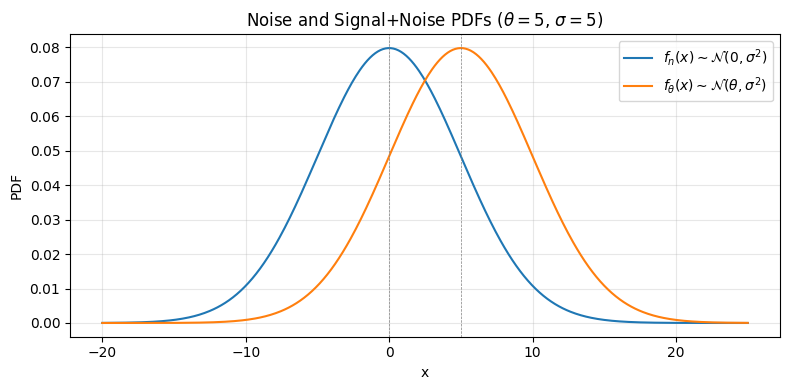

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

theta = 5
sigma = 5

x = np.linspace(-20, 25, 500)

fn = norm.pdf(x, loc=0, scale=sigma)       # f_n(x): noise PDF, N(0, sigma^2)
ftheta = norm.pdf(x, loc=theta, scale=sigma)  # f_theta(x): signal+noise PDF, N(theta, sigma^2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, fn, label=r'$f_n(x) \sim \mathcal{N}(0, \sigma^2)$')
ax.plot(x, ftheta, label=r'$f_\theta(x) \sim \mathcal{N}(\theta, \sigma^2)$')
ax.axvline(0, color='grey', linestyle='--', linewidth=0.5)
ax.axvline(theta, color='grey', linestyle='--', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('PDF')
ax.set_title(rf'Noise and Signal+Noise PDFs ($\theta={theta}$, $\sigma={sigma}$)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

With $\theta / \sigma = 1$, the mean of the signal is only separated from the noise by 0.5 standard deviation. Critical applications aim for $6\sigma$ separation, therefore I would not trust my life to this detector.

### c) For the given problem, we may design a CFAR detector with PF A = 0.1. If we do so:
• What would then the threshold be?

• How large is PD in this case?

• Indicate the threshold in the figure made in b).

• In the same figure, do also indicate which area PF A and PD represent.

**Threshold:** For a CFAR detector with $P_{FA} = 0.1$, we need:

$$
P_{FA} = \int_{x_c}^{\infty} f_n(x)\,dx = Q\!\left(\frac{x_c}{\sigma}\right) = 0.1
$$

Solving for $x_c$:

$$
x_c = \sigma \cdot Q^{-1}(0.1) = 5 \cdot 1.2816 \approx 6.41
$$

**Probability of Detection:**

$$
P_D = \int_{x_c}^{\infty} f_\theta(x)\,dx = Q\!\left(\frac{x_c - \theta}{\sigma}\right) = Q\!\left(\frac{6.41 - 5}{5}\right) = Q(0.282) \approx 0.389
$$

Threshold x_c = 6.4078
P_D = 0.3891


Threshold x_c = 6.4078
P_D = 0.3891


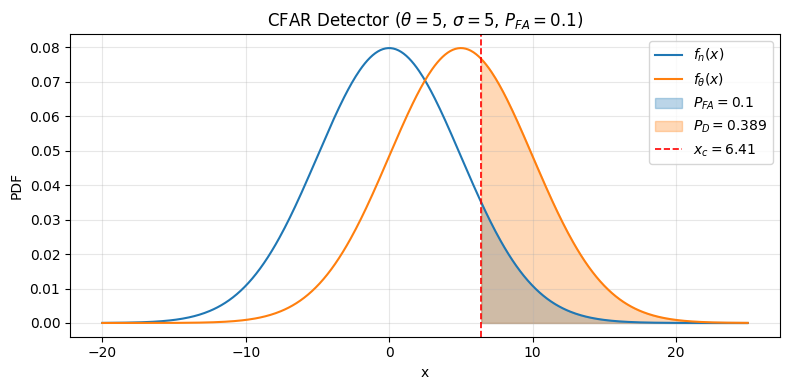

In [3]:
from scipy.stats import norm as norm_dist

theta = 5
sigma = 5
P_FA = 0.1

# Threshold: Q(x_c/sigma) = P_FA  =>  x_c = sigma * Q^{-1}(P_FA)
# Q^{-1}(p) = Phi^{-1}(1-p), so x_c = sigma * ppf(1 - P_FA)
x_c = sigma * norm_dist.ppf(1 - P_FA)
print(f"Threshold x_c = {x_c:.4f}")

# Probability of detection: P_D = Q((x_c - theta) / sigma)
P_D = 1 - norm_dist.cdf((x_c - theta) / sigma)
print(f"P_D = {P_D:.4f}")

# --- Plot ---
x = np.linspace(-20, 25, 500)
fn = norm_dist.pdf(x, loc=0, scale=sigma)
ftheta = norm_dist.pdf(x, loc=theta, scale=sigma)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, fn, label=r'$f_n(x)$')
ax.plot(x, ftheta, label=r'$f_\theta(x)$')

# Shade P_FA: area under f_n(x) for x > x_c
x_pfa = x[x >= x_c]
ax.fill_between(x_pfa, norm_dist.pdf(x_pfa, 0, sigma), alpha=0.3, color='C0',
                label=rf'$P_{{FA}} = {P_FA}$')

# Shade P_D: area under f_theta(x) for x > x_c
x_pd = x[x >= x_c]
ax.fill_between(x_pd, norm_dist.pdf(x_pd, theta, sigma), alpha=0.3, color='C1',
                label=rf'$P_D = {P_D:.3f}$')

# Threshold line
ax.axvline(x_c, color='red', linestyle='--', linewidth=1.2,
           label=rf'$x_c = {x_c:.2f}$')

ax.set_xlabel('x')
ax.set_ylabel('PDF')
ax.set_title(rf'CFAR Detector ($\theta={theta}$, $\sigma={sigma}$, $P_{{FA}}={P_FA}$)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### d) We now consider a detector where we assume equal probability of receiving noise and signal+noise. The noise and signal+noise has the PDFs and parameters as above (i.e. θ = 5 and σ =5). For this detector, we want experimentally to find the ROC curve of the detector.

Construct the "true" and measured data (when using Matlab) as

theta = 5;

sigma = 5;

nData = 1000;

s = theta * (randn(nData,1)>=0); % "true" data

x = s + sigma*randn(size(s)); % measured data

• Estimate and plot the ROC curve for this detector.

• In the same figure, plot the true (expected) ROC curve.

• Runseveral realization of the random "true" data and comment on your results

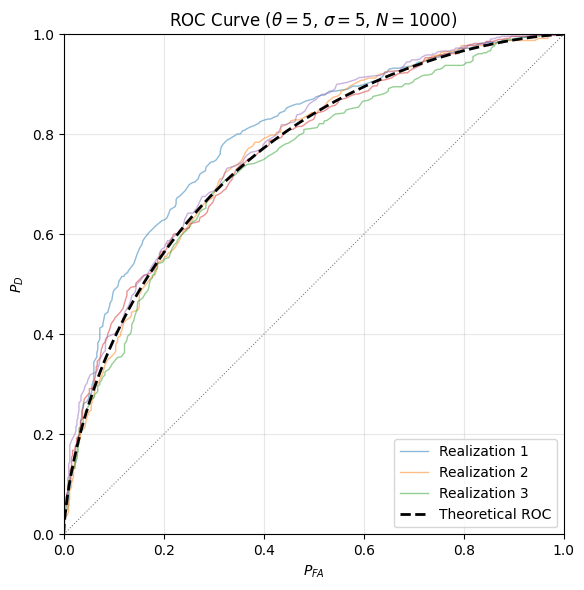

In [10]:
from scipy.stats import norm as norm_dist

theta = 5
sigma = 5
nData = 1000
d_prime = theta / sigma  # deflection coefficient

# --- Theoretical ROC curve ---
# P_FA = Q(x_c / sigma), P_D = Q(x_c/sigma - theta/sigma) = Q(Q^{-1}(P_FA) - d')
pfa_theory = np.linspace(1e-6, 1 - 1e-6, 1000)
pd_theory = norm_dist.sf(norm_dist.isf(pfa_theory) - d_prime)  # sf = Q function, isf = Q^{-1}

# --- Empirical ROC curves (multiple realizations) ---
n_realizations = 5
fig, ax = plt.subplots(figsize=(7, 6))

for i in range(n_realizations):
    # Generate data: equal probability of H0 (s=0) and H1 (s=theta)
    s = theta * (np.random.randn(nData) >= 0).astype(float)  # "true" signal
    x = s + sigma * np.random.randn(nData)                    # measured data

    # Ground truth labels
    labels = (s > 0).astype(int)  # 1 if H1, 0 if H0

    # Sweep thresholds to build empirical ROC
    thresholds = np.linspace(x.min() - 1, x.max() + 1, 500)
    pfa_emp = np.array([np.mean(x[labels == 0] >= t) for t in thresholds])
    pd_emp = np.array([np.mean(x[labels == 1] >= t) for t in thresholds])

    ax.plot(pfa_emp, pd_emp, alpha=0.5, linewidth=1,
            label=f'Realization {i+1}' if i < 3 else None)

# Plot a small visualization of the detection threshold on the PDFs


# Plot theoretical ROC
ax.plot(pfa_theory, pd_theory, 'k--', linewidth=2, label='Theoretical ROC')

# Diagonal (chance line)
ax.plot([0, 1], [0, 1], ':', color='grey', linewidth=0.8)

ax.set_xlabel(r'$P_{FA}$')
ax.set_ylabel(r'$P_D$')
ax.set_title(rf'ROC Curve ($\theta={theta}$, $\sigma={sigma}$, $N={nData}$)')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



### e) We wish to improve our detector and decide to use more than one measurement when transmitting, and then also detecting noise or signal+noise, ie.

H′
0: x_n = n_n, for n = 1,...,N.

H′
1: x_n = θ +n_n, for n = 1,...,N.

We choose to use the sample mean as our sufficient statistics.

• Find the joint PDFs of this statistics as a function of the number of measurements used.

• Constructing a CFAR detector, what is the least number of measurements (N) we need if
we want PFA =0.01 and PD > 0.9

$$
f_{x|H0}(x) = \frac{1}{\sqrt{2\pi\sigma^2/N}} \exp\!\left(-\frac{(x)^2}{2\sigma^2/N}\right)
$$



$$
f_{x|H1}(x) = \frac{1}{\sqrt{2\pi\sigma^2/N}} \exp\!\left(-\frac{(x - \theta)^2}{2\sigma^2/N}\right)
$$

More samples is like boosting, but it is not boosting. It is just that with more samples, the variance drops causing the PDFs to be more seperable.

**Minimum $N$:** The CFAR threshold for the sample mean is:

$$
P_{FA} = Q\!\left(\frac{x_c}{\sigma/\sqrt{N}}\right) = 0.01 \quad \Longrightarrow \quad x_c = \frac{\sigma}{\sqrt{N}}\, Q^{-1}(0.01)
$$

The detection probability requirement is:

$$
P_D = Q\!\left(\frac{x_c - \theta}{\sigma/\sqrt{N}}\right) = Q\!\left(Q^{-1}(P_{FA}) - \frac{\theta\sqrt{N}}{\sigma}\right) > 0.9
$$

Since $Q$ is monotonically decreasing, $P_D > 0.9$ requires:

$$
Q^{-1}(P_{FA}) - \frac{\theta\sqrt{N}}{\sigma} < Q^{-1}(0.9) = -Q^{-1}(0.1)
$$

Solving for $N$:

$$
N \geq \left(\frac{\sigma}{\theta}\right)^2 \bigl(Q^{-1}(P_{FA}) + Q^{-1}(1 - P_D)\bigr)^2
$$

### f) For the value of N found in e), plot the joint PDFs in the same way as in b) and indicate the threshold found. Comment your results

Q^{-1}(P_FA)   = 2.3263
Q^{-1}(1-P_D)  = 1.2816
N (continuous)  = 13.02
N_min (ceil)    = 14

Verification at N = 14:
  x_c  = 3.1087
  P_D  = 0.9215  (requirement: > 0.9)


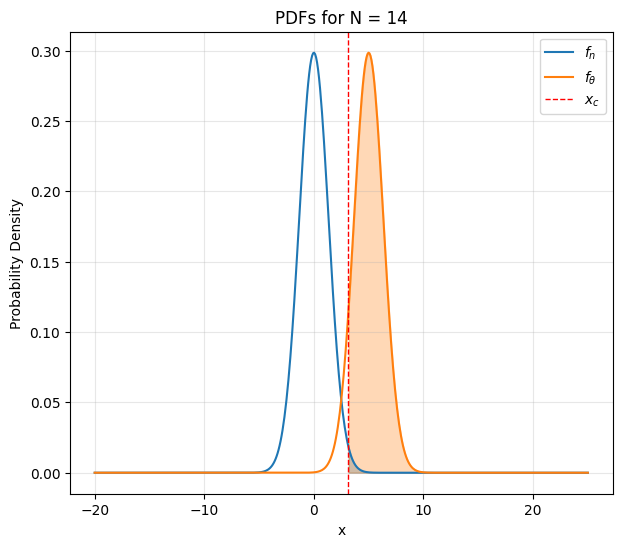

In [ ]:
from scipy.stats import norm as norm_dist

theta = 5
sigma = 5
P_FA_target = 0.01
P_D_target = 0.9

q_inv_pfa = norm_dist.isf(P_FA_target)
q_inv_1_pd = norm_dist.isf(1 - P_D_target)

N_min_cont = (sigma / theta)**2 * (q_inv_pfa + q_inv_1_pd)**2
N_min = int(np.ceil(N_min_cont))

print(f"Q^{{-1}}(P_FA)   = {q_inv_pfa:.4f}")
print(f"Q^{{-1}}(1-P_D)  = {q_inv_1_pd:.4f}")
print(f"N (continuous)  = {N_min_cont:.2f}")
print(f"N_min (ceil)    = {N_min}")

# Verify: compute actual P_D at N_min
x_c = (sigma / np.sqrt(N_min)) * q_inv_pfa
P_D_actual = norm_dist.sf((x_c - theta) / (sigma / np.sqrt(N_min)))
print(f"\nVerification at N = {N_min}:")
print(f"  x_c  = {x_c:.4f}")
print(f"  P_D  = {P_D_actual:.4f}  (requirement: > 0.9)")

# Plot the PDFs for N_min samples
x = np.linspace(-20, 25, 500)
fn = norm_dist.pdf(x, loc=0, scale=sigma/np.sqrt(N_min))
ftheta = norm_dist.pdf(x, loc=theta, scale=sigma/np.sqrt(N_min))

plt.figure(figsize=(7, 6))
plt.plot(x, fn, label=r'$f_n$')
plt.plot(x, ftheta, label=r'$f_\theta$')
plt.axvline(x_c, color='red', linestyle='--', linewidth=1, label=rf'$x_c$')
plt.fill_between(x[x >= x_c], fn[x >= x_c], alpha=0.3, color='C0')
plt.fill_between(x[x >= x_c], ftheta[x >= x_c], alpha=0.3, color='C1')
plt.title(f'PDFs for N = {N_min}')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
